# Bag of Words with Advanced Features

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import re 
from bs4 import BeautifulSoup

import warnings
warnings.filterwarnings('ignore')

from nltk.corpus import stopwords

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score


In [2]:
df = pd.read_csv("Duplicate Question.csv")
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [3]:
df = df.sample(30000,random_state=2) 
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0


# Basic Preprocessing

In [4]:
def preprocess(q): 

    q = str(q).lower().strip() 

    # Replace certain special characters with their string equivalents 
    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')
    
    # The pattern '[math]' appears around 900 times in the whole dataset.
    q = q.replace('[math]', '')
    
    # Replacing some numbers with string equivalents (not perfect, can be done better to account for more cases)
    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)
    
    # Decontracting words
    # https://en.wikipedia.org/wiki/Wikipedia%3aList_of_English_contractions
    # https://stackoverflow.com/a/19794953
    contractions = { 
    "ain't": "am not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
    }

    q_decontracted = []

    for word in q.split():
        if word in contractions:
            word = contractions[word]
        q_decontracted.append(word)
        

    q = ' '.join(q_decontracted)

    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")
    
    # Removing HTML tags
    q = BeautifulSoup(q)
    q = q.get_text()
    
    # Remove punctuations
    pattern = re.compile('\W')
    q = re.sub(pattern, ' ', q).strip()

    
    return q
    

In [5]:
preprocess("I've already completed ? my . <b>camplusx</b> course")

'i have already completed   my   camplusx course'

In [6]:
df['question1'] = df['question1'].apply(preprocess)
df['question2'] = df['question2'].apply(preprocess) 
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0


In [7]:
# Len of q1 , q2
df['q1_len'] = df['question1'].str.len() 
df['q2_len'] = df['question2'].str.len()

In [8]:
# Total words in q1 , q2
df['q1_words'] = df['question1'].apply(lambda row: len(row.split(' ')))
df['q2_words'] = df['question2'].apply(lambda row:len(row.split(' ')))

In [9]:
# Common words in q1 and q2
def common_words(row): 
    w1 = set(map(lambda word: word.lower().strip() ,row['question1'].split(" ")))
    w2 = set(map(lambda word:word.lower().strip(),row['question2'].split(' ')))
    return len(w1 & w2)

df['word_common'] =  df.apply(common_words,axis=1)

In [10]:
# Total words in q1 and q2 
def total_words(row): 
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(' ')))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(' ')))
    return (len(w1) + len(w2))
df['total_words'] = df.apply(total_words,axis=1)

In [11]:
# Ratio of common words sharing 
df['word_share'] = round(df['word_common'] / df['total_words'])

In [12]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,word_common,total_words,word_share
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,12,26,0.0
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,8,24,0.0
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,4,38,0.0
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,14,32,1,34,0.0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,3,13,0.0


# 🚀 Advanced Feature Engineering

This section outlines the advanced features extracted to capture linguistic, structural, and semantic overlaps between the question pairs.

---

## 1. Token Features
These features capture word-level overlaps by analyzing common words, stop words, and overall token counts.

*   **`cwc_min`** (Common Word Count Min): The ratio of common non-stop words to the length of the smaller question.
    $$\text{cwc\_min} = \frac{\text{Common Words}}{\min(\text{len}(Q_1), \text{len}(Q_2))}$$
*   **`cwc_max`** (Common Word Count Max): The ratio of common non-stop words to the length of the larger question.
    $$\text{cwc\_max} = \frac{\text{Common Words}}{\max(\text{len}(Q_1), \text{len}(Q_2))}$$
*   **`csc_min`** (Common Stop Words Min): The ratio of common stop words to the smaller stop word count.
*   **`csc_max`** (Common Stop Words Max): The ratio of common stop words to the larger stop word count.
*   **`ctc_min`** (Common Token Count Min): The ratio of common tokens (words + stop words) to the smaller token count.
*   **`ctc_max`** (Common Token Count Max): The ratio of common tokens (words + stop words) to the larger token count.
*   **`last_word_eq`**: Binary flag ($1$ if the last words match, $0$ otherwise).
*   **`first_word_eq`**: Binary flag ($1$ if the first words match, $0$ otherwise).

---

## 2. Length-Based Features
These features capture structural and scale differences between the two text inputs.

*   **`mean_len`**: Average length of the two questions (by word count).
*   **`abs_len_diff`**: Absolute difference in length between the two questions:
    $$|\text{len}(Q_1) - \text{len}(Q_2)|$$
*   **`longest_substr_ratio`**: Ratio of the longest common substring length to the length of the smaller question:
    $$\frac{\text{len}(\text{Longest Substring})}{\min(\text{len}(Q_1), \text{len}(Q_2))}$$

---

## 3. Fuzzy Features
Levenshtein-distance-based similarity scores from the `fuzzywuzzy` / `RapidFuzz` library to handle misspellings and word order variations.

*   **`fuzz_ratio`**: Standard edit distance ratio comparing the raw character sequences.
*   **`fuzz_partial_ratio`**: A ratio calculated by looking at the best matching substring of the longer string.
*   **`token_sort_ratio`**: Sorts the tokens alphabetically before calculating the ratio, ignoring word order.
*   **`token_set_ratio`**: Extracts unique common tokens and calculates the overlap, making it robust to duplicates and noise.

---



# 1. Token Features

In [13]:
STOP_WORDS = set(stopwords.words('english'))

def fetch_token_features(row):
    # Ensure inputs are treated as strings to prevent errors with missing/NaN values
    q1 = str(row['question1'])
    q2 = str(row['question2']) 

    safe = 0.0000001
    
    # Split sentences into word lists
    q1_token = q1.split()
    q2_token = q2.split() 
    
    # Handle empty rows safely
    if len(q1_token) == 0 or len(q2_token) == 0:
        return [0.0] * 8

    # Non-Stopwords (FIXED: Separated q1 and q2, using the fast STOP_WORDS set)
    q1_words = set([i for i in q1_token if i not in STOP_WORDS])
    q2_words = set([i for i in q2_token if i not in STOP_WORDS])

    # Stopwords (FIXED: Separated q1 and q2, using the fast STOP_WORDS set)
    q1_stop = set([i for i in q1_token if i in STOP_WORDS])
    q2_stop = set([i for i in q2_token if i in STOP_WORDS])

    # Get the common counts (FIXED: intersecting q1_words with q2_words instead of raw string)
    common_word_count = len(q1_words.intersection(q2_words)) 
    common_stop_count = len(q1_stop.intersection(q2_stop))
    common_token_count = len(set(q1_token).intersection(set(q2_token))) 

    token_features = [0.0] * 8

    # Calculate min/max ratios (FIXED: corrected token_features[3] to look at both q1 and q2)
    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + safe) 
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + safe)  
    token_features[2] = common_stop_count / (min(len(q1_stop), len(q2_stop)) + safe) 
    token_features[3] = common_stop_count / (max(len(q1_stop), len(q2_stop)) + safe)
    token_features[4] = common_token_count / (min(len(q1_token), len(q2_token)) + safe)
    token_features[5] = common_token_count / (max(len(q1_token), len(q2_token)) + safe)

    # First and last word equality checks
    token_features[6] = int(q1_token[-1] == q2_token[-1])
    token_features[7] = int(q1_token[0] == q2_token[0])

    return token_features

In [14]:
features_list = list(df.apply(fetch_token_features, axis=1))

In [15]:
cols = ["cwc_min", "cwc_max", "csc_min", "csc_max", "ctc_min", "ctc_max", "last_word_eq", "first_word_eq"]
df[cols] = features_list

In [16]:
print(df.shape)
df.head()

(30000, 21)


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,...,total_words,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,26,0.0,0.875000,0.875,1.000000,1.000000,0.923077,0.923077,1.0,1.0
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,...,24,0.0,0.666667,0.500,0.714286,0.625000,0.583333,0.466667,1.0,1.0
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,...,38,0.0,0.000000,0.000,0.428571,0.272727,0.150000,0.115385,0.0,0.0
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,14,32,...,34,0.0,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,13,0.0,0.750000,0.600,0.000000,0.000000,0.600000,0.333333,1.0,0.0


# 2. Length-Based Features

In [17]:
import distance


In [18]:
def fetch_length_features(row):
    
    q1 = str(row['question1'])
    q2 = str(row['question2'])
    
    length_features = [0.0]*3
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features
    
    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))
    
    #Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens))/2
    
    strs = list(distance.lcsubstrings(q1, q2))
    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)
    
    return length_features

In [19]:
length_features = df.apply(fetch_length_features, axis=1)

In [20]:

df['abs_len_diff'] = list(map(lambda x: x[0], length_features))
df['mean_len'] = list(map(lambda x: x[1], length_features))
df['longest_substr_ratio'] = list(map(lambda x: x[2], length_features))
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,0.875,1.000000,1.000000,0.923077,0.923077,1.0,1.0,0.0,13.0,0.855263
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,...,0.500,0.714286,0.625000,0.583333,0.466667,1.0,1.0,3.0,13.5,0.224490
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,...,0.000,0.428571,0.272727,0.150000,0.115385,0.0,0.0,6.0,23.0,0.047619
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,14,32,...,0.000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,17.0,21.5,0.050847
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,0.600,0.000000,0.000000,0.600000,0.333333,1.0,0.0,4.0,7.0,0.542857


# 3. Fuzzy Features

In [21]:
from fuzzywuzzy import fuzz

In [22]:
def fetch_fuzzy_features(row):
    
    q1 = row['question1']
    q2 = row['question2']
    
    fuzzy_features = [0.0]*4
    
    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [23]:
fuzzy_features = df.apply(fetch_fuzzy_features, axis=1)

In [24]:
# Creating new feature columns for fuzzy features
df['fuzz_ratio'] = list(map(lambda x: x[0], fuzzy_features))
df['fuzz_partial_ratio'] = list(map(lambda x: x[1], fuzzy_features))
df['token_sort_ratio'] = list(map(lambda x: x[2], fuzzy_features))
df['token_set_ratio'] = list(map(lambda x: x[3], fuzzy_features))

In [25]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,0.923077,1.0,1.0,0.0,13.0,0.855263,99,99,99,99
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,...,0.466667,1.0,1.0,3.0,13.5,0.224490,69,67,65,74
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,...,0.115385,0.0,0.0,6.0,23.0,0.047619,26,29,34,43
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,14,32,...,0.000000,0.0,0.0,17.0,21.5,0.050847,29,41,23,30
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,0.333333,1.0,0.0,4.0,7.0,0.542857,55,70,48,69


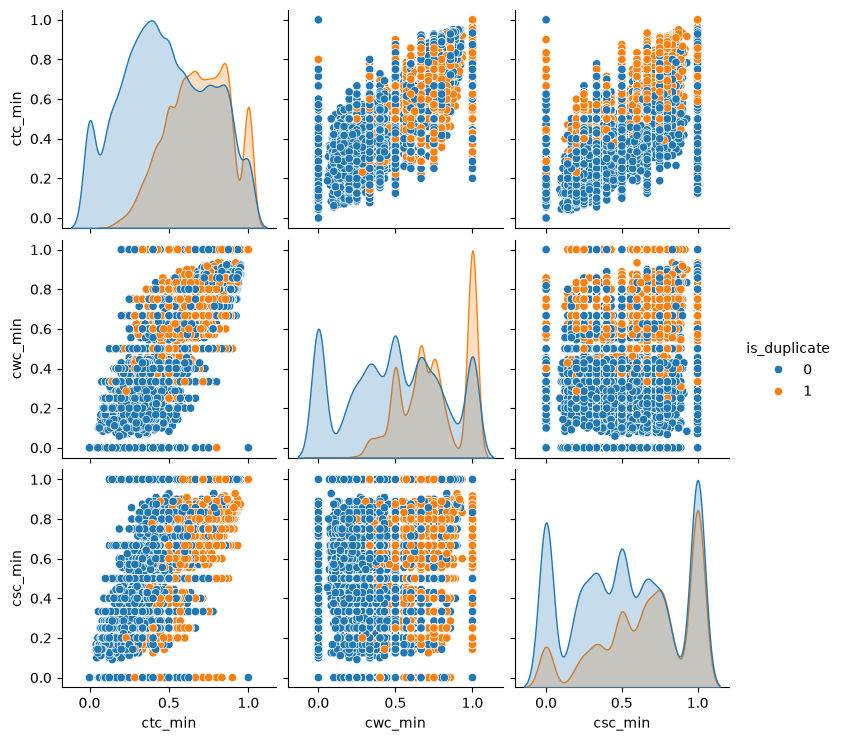

In [26]:
sns.pairplot(df[['ctc_min', 'cwc_min', 'csc_min', 'is_duplicate']],hue='is_duplicate')

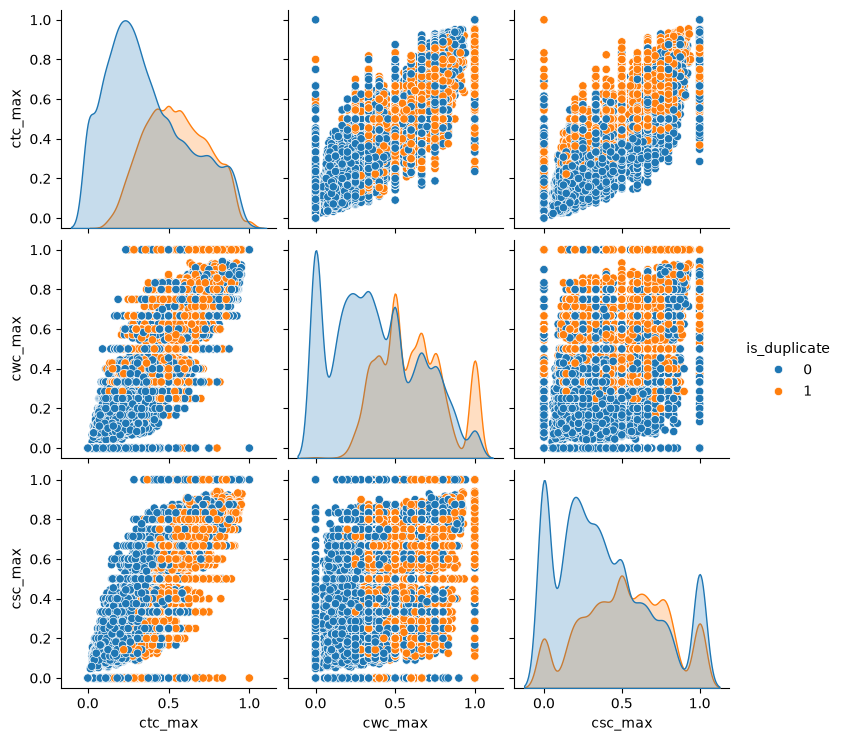

In [27]:
sns.pairplot(df[['ctc_max', 'cwc_max', 'csc_max', 'is_duplicate']],hue='is_duplicate')

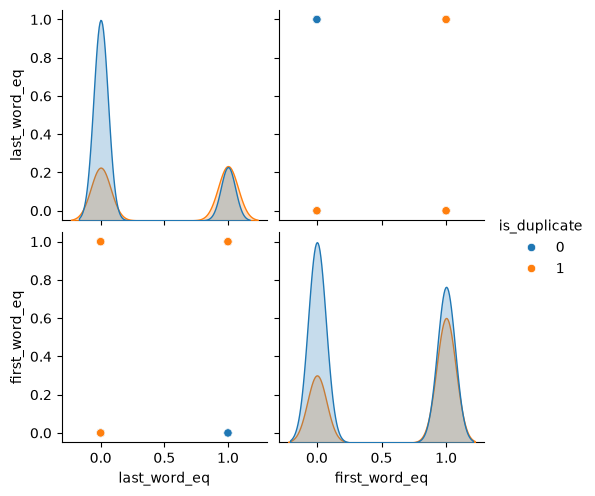

In [28]:
sns.pairplot(df[['last_word_eq', 'first_word_eq', 'is_duplicate']],hue='is_duplicate')

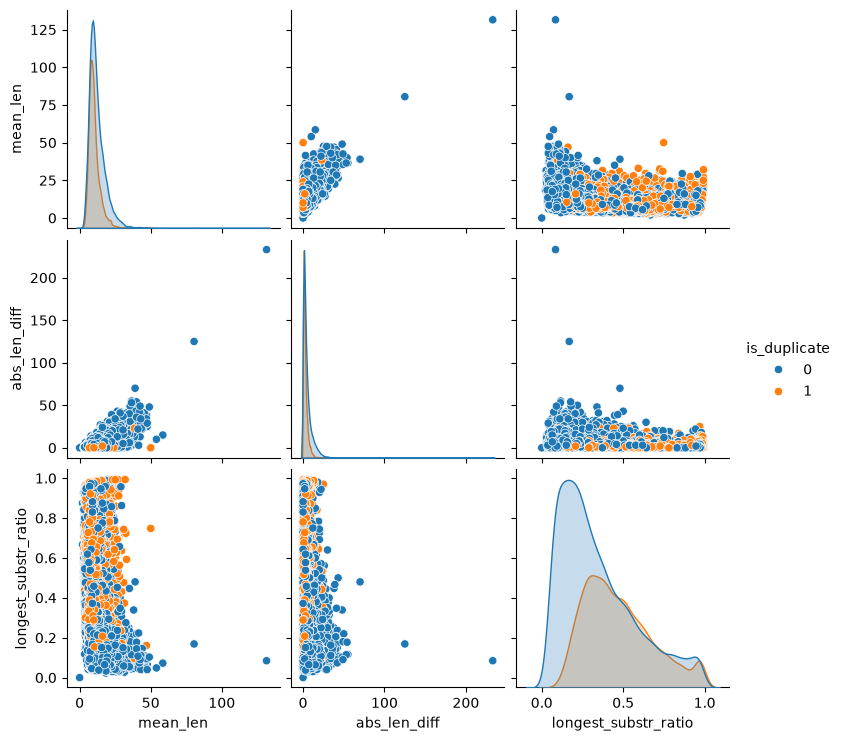

In [29]:
sns.pairplot(df[['mean_len', 'abs_len_diff','longest_substr_ratio', 'is_duplicate']],hue='is_duplicate')

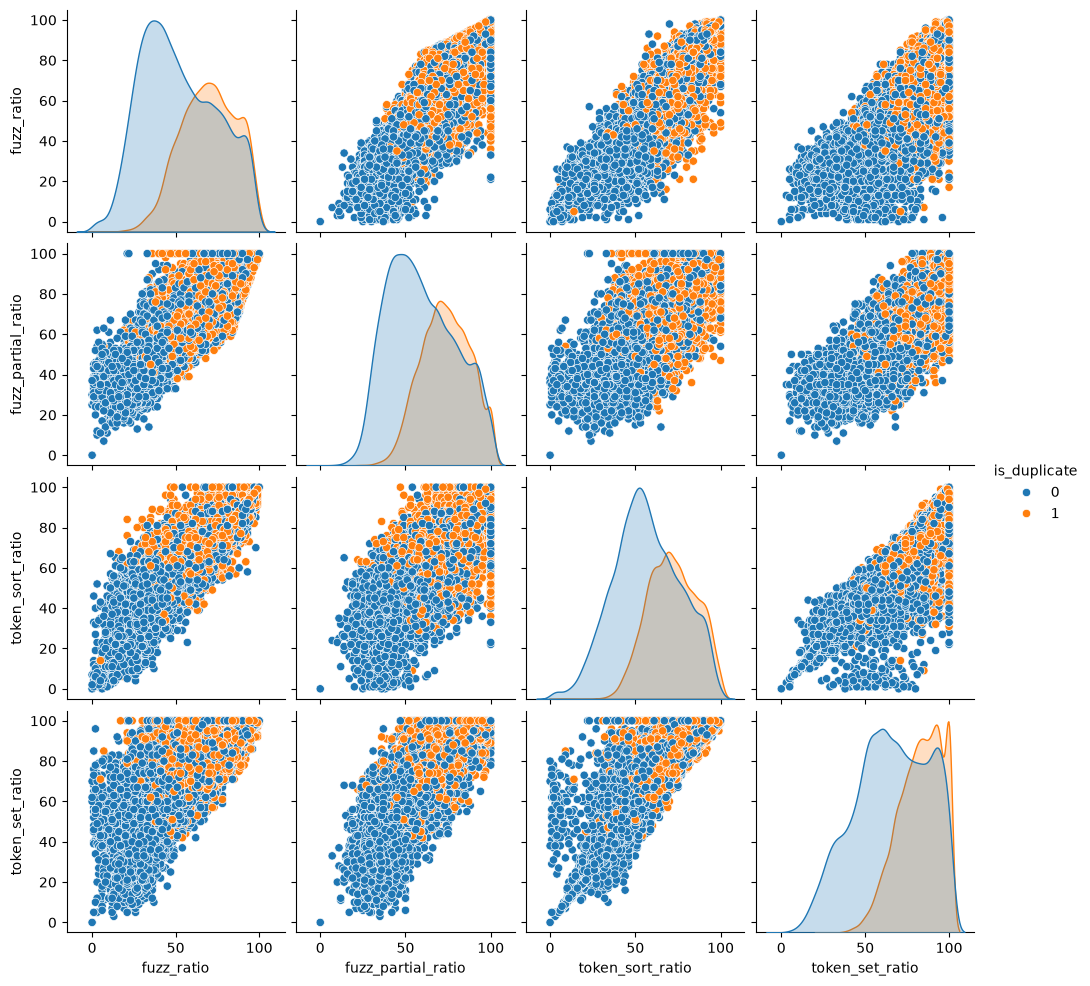

In [30]:
sns.pairplot(df[['fuzz_ratio', 'fuzz_partial_ratio','token_sort_ratio','token_set_ratio', 'is_duplicate']],hue='is_duplicate')

# Dimensionality Reduction (using T-sne)

In [31]:
# Using TSNE for Dimentionality reduction for 15 Features(Generated after cleaning the data) to 3 dimention

from sklearn.preprocessing import MinMaxScaler

X = MinMaxScaler().fit_transform(df[['cwc_min', 'cwc_max', 'csc_min', 'csc_max' , 'ctc_min' , 'ctc_max' , 'last_word_eq', 'first_word_eq' , 'abs_len_diff' , 'mean_len' , 'token_set_ratio' , 'token_sort_ratio' ,  'fuzz_ratio' , 'fuzz_partial_ratio' , 'longest_substr_ratio']])
y = df['is_duplicate'].values

In [32]:
from sklearn.manifold import TSNE

tsne2d = TSNE(
    n_components=2,
    init='random', # pca
    random_state=101,
    method='barnes_hut',
    n_iter_without_progress=1000,
    verbose=2,
    angle=0.5,
).fit_transform(X)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.196s...
[t-SNE] Computed neighbors for 30000 samples in 16.587s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sa

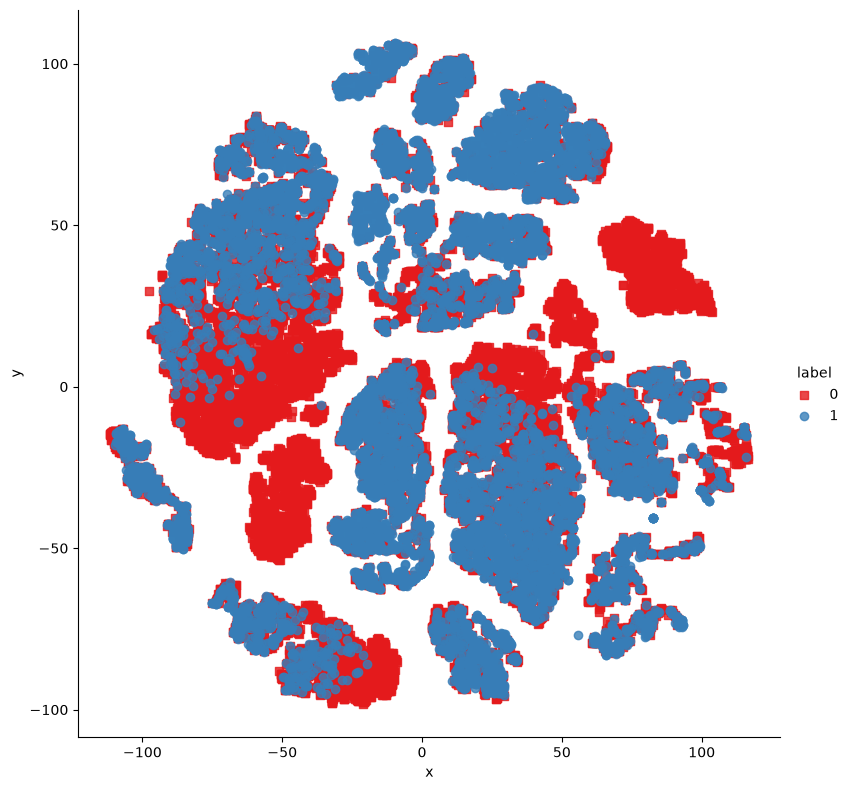

In [33]:
x_df = pd.DataFrame({'x':tsne2d[:,0], 'y':tsne2d[:,1] ,'label':y})

# draw the plot in appropriate place in the grid
sns.lmplot(data=x_df, x='x', y='y', hue='label', fit_reg=False, height=8,palette="Set1",markers=['s','o'])

In [34]:
ques_df = df[['question1','question2']]
ques_df.head()

,question1,question2
398782,what is the best marketing automation tool for...,what is the best marketing automation tool for...
115086,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...
327711,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...
367788,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...
151235,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy


In [35]:
final_df = df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(30000, 23)


,is_duplicate,q1_len,q2_len,q1_words,q2_words,word_common,total_words,word_share,cwc_min,cwc_max,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,1,75,76,13,13,12,26,0.0,0.875000,0.875,...,0.923077,1.0,1.0,0.0,13.0,0.855263,99,99,99,99
115086,0,48,56,13,16,8,24,0.0,0.666667,0.500,...,0.466667,1.0,1.0,3.0,13.5,0.224490,69,67,65,74
327711,0,104,119,28,21,4,38,0.0,0.000000,0.000,...,0.115385,0.0,0.0,6.0,23.0,0.047619,26,29,34,43
367788,0,58,145,14,32,1,34,0.0,0.000000,0.000,...,0.000000,0.0,0.0,17.0,21.5,0.050847,29,41,23,30
151235,0,34,49,5,9,3,13,0.0,0.750000,0.600,...,0.333333,1.0,0.0,4.0,7.0,0.542857,55,70,48,69


In [36]:
from sklearn.feature_extraction.text import CountVectorizer
# merge texts
questions = list(ques_df['question1']) + list(ques_df['question2'])

cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [37]:
temp_df1 = pd.DataFrame(q1_arr, index= ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index= ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape

(30000, 6000)

In [38]:
final_df = pd.concat([final_df, temp_df], axis=1)
print(final_df.shape)
final_df.head()

(30000, 6023)


,is_duplicate,q1_len,q2_len,q1_words,q2_words,word_common,total_words,word_share,cwc_min,cwc_max,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,1,75,76,13,13,12,26,0.0,0.875000,0.875,...,0,0,0,0,0,0,0,0,0,0
115086,0,48,56,13,16,8,24,0.0,0.666667,0.500,...,0,0,0,0,0,0,0,0,0,0
327711,0,104,119,28,21,4,38,0.0,0.000000,0.000,...,0,0,0,0,0,0,0,0,0,0
367788,0,58,145,14,32,1,34,0.0,0.000000,0.000,...,0,0,0,1,0,0,0,0,0,0
151235,0,34,49,5,9,3,13,0.0,0.750000,0.600,...,0,0,0,0,0,0,0,0,0,0


In [39]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.2,random_state=1)

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7893333333333333

In [41]:
print('Random Forest Confusion matrix ')
confusion_matrix(y_test,y_pred)

Random Forest Confusion matrix 


array([[3291,  521],
       [ 743, 1445]])

In [42]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred1 = xgb.predict(X_test)
accuracy_score(y_test,y_pred1)

0.7928333333333333

In [43]:
print('XG boost Confusion Matrix ')
confusion_matrix(y_test,y_pred1)

XG boost Confusion Matrix 


array([[3233,  579],
       [ 664, 1524]])